1. What is Anomaly Detection? Explain its types (point, contextual, and
collective anomalies) with examples.

Ans. Anomaly Detection is the process of identifying data points, events, or observations that differ significantly from normal behavior or expected patterns in a dataset. These unusual patterns are called anomalies or outliers and may indicate errors, fraud, faults, or rare events.A point anomaly occurs when a single data point is significantly different from the rest of the data.In a dataset of daily temperatures ranging between 25°C and 35°C, a value of 60°C on one day is a point anomaly.A contextual anomaly occurs when a data point is abnormal in a specific context, such as time, location, or condition, even though it may be normal in another context.A temperature of 15°C may be normal in winter but considered anomalous during summer.A collective anomaly occurs when a group of related data points behaves abnormally together, even if individual data points may appear normal.In network traffic monitoring, a sudden sequence of repeated login attempts from different IP addresses may indicate a cyberattack, even though each login attempt alone appears normal.

2.  Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of
their approach and suitable use cases.

Ans. Isolation Forest is an anomaly detection algorithm that identifies anomalies by randomly splitting data points using decision trees. Anomalies are isolated more quickly because they are fewer and different from normal data while DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups closely packed data points and labels isolated points as anomalies or noise while Local Outlier Factor is an anomaly detection method that identifies anomalies by comparing the local density of a data point with the densities of its neighboring points.

3. What are the key components of a Time Series? Explain each with one
example.

Ans. A Time Series is a sequence of data points collected or recorded at regular time intervals. It consists of several components that help in understanding patterns and behavior over time.The trend component represents the long-term movement or direction of data over a period of time. It may show an increasing, decreasing, or stable pattern.The steady increase in online shopping sales over several years shows an upward trend.The seasonal component represents regular and repeating patterns that occur at fixed intervals due to seasonal factors such as months, quarters, or festivals.Ice cream sales increase every summer and decrease during winter each year.The cyclical component refers to fluctuations that occur over long periods due to economic or business cycles. These patterns are not fixed or regular like seasonal variations.A country’s economy may experience periods of growth and recession over several years.The irregular or random component consists of unpredictable variations caused by unexpected events or random factors.A sudden drop in airline bookings during a natural disaster or pandemic is an irregular component.

4.  Define Stationary in time series. How can you test and transform a
non-stationary series into a stationary one?

Ans.A stationary time series is a time series whose statistical properties, such as mean, variance, and autocorrelation, remain constant over time. In a stationary series, the data does not show long-term trends or changing seasonal patterns.Testing stationarity in a time series means checking whether the statistical properties such as mean, variance, and autocorrelation remain constant over time. It can be tested through visual inspection by observing the graph of the series, or by using statistical methods such as the Augmented Dickey-Fuller Test and the KPSS Test, which help determine whether the series is stationary or non-stationary.Transforming a non-stationary series into a stationary series means applying techniques that remove trends, seasonality, or changing variance from the data. Common transformation methods include differencing, which removes trends by subtracting consecutive observations; log transformation, which stabilizes variance; detrending, which removes long-term movement; and seasonal adjustment, which removes repeating seasonal patterns.

5.  Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in
terms of structure and application.

Ans. The Autoregressive Model is a time series model in which the current value of a variable depends on its previous values. It is mainly used when past observations have a strong influence on future values while The Moving Average Model is a model in which the current value depends on past forecast errors or random shocks. It is useful for capturing short-term fluctuations and noise in time series data while The ARIMA combines autoregressive (AR), differencing (I), and moving average (MA) components to model non-stationary time series data. It is widely used for forecasting data with trends but without seasonal patterns while The SARIMA is an extension of ARIMA that includes seasonal components along with AR, differencing, and MA terms. It is used for forecasting time series data with repeating seasonal patterns while The SARIMAX is an advanced version of SARIMA that also includes external or exogenous variables affecting the time series. It is used when forecasting depends not only on past values and seasonality but also on additional influencing factors such as weather, promotions, or economic indicators.

/tmp/ipykernel_5275/3984292578.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index=pd.date_range(start='1949-01', periods=len(data), freq='M'))


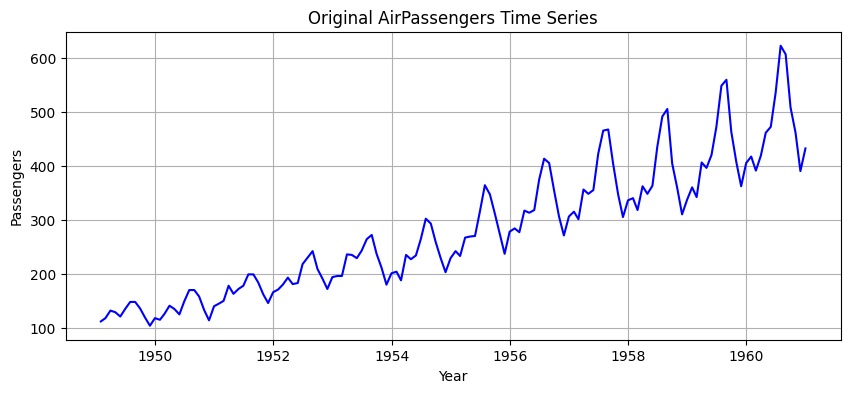

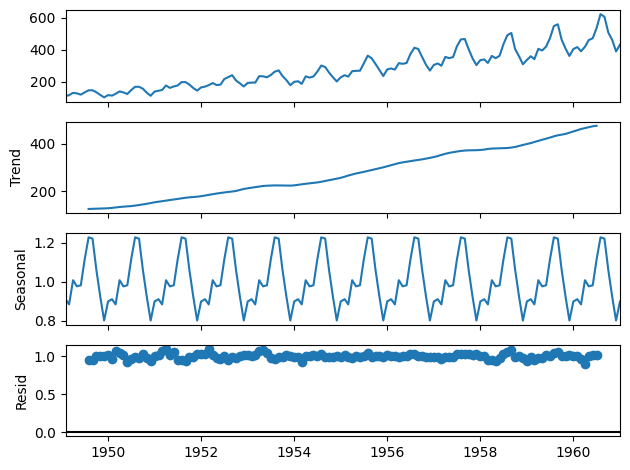

In [ ]:
''' 6.Load a time series dataset (e.g., AirPassengers), plot the original series,
and decompose it into trend, seasonality, and residual components'''


import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

from statsmodels.datasets import get_rdataset

data = get_rdataset("AirPassengers").data

ts = pd.Series(data['value'].values,
               index=pd.date_range(start='1949-01', periods=len(data), freq='M'))

plt.figure(figsize=(10, 4))
plt.plot(ts, color='blue')
plt.title("Original AirPassengers Time Series")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()

decomposition = seasonal_decompose(ts, model='multiplicative')

decomposition.plot()
plt.show()

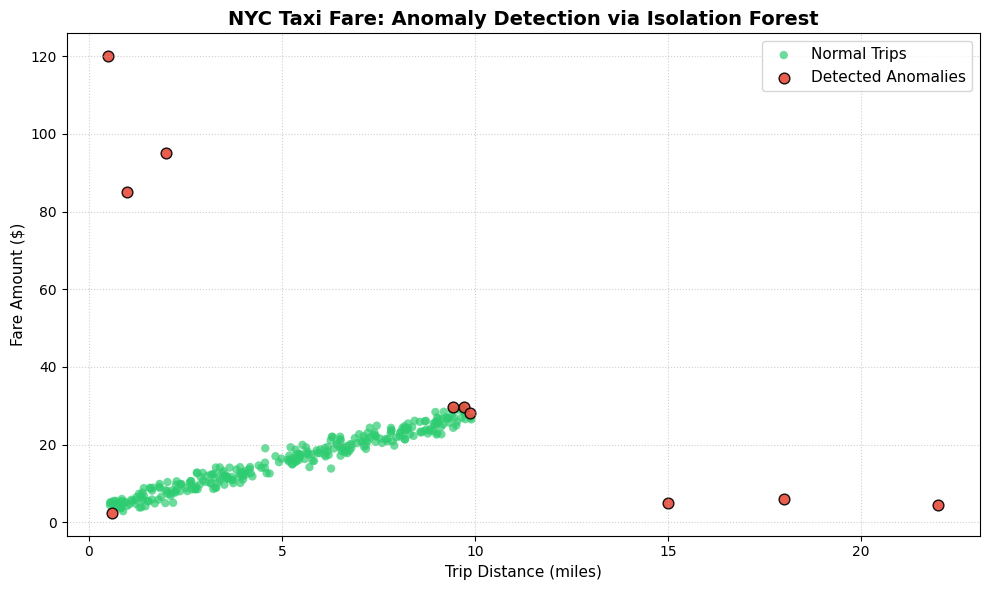

In [4]:
''' 7.Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to
detect anomalies. Visualize the anomalies on a 2D scatter plot.'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

np.random.seed(42)
n_samples = 300

distance = np.random.uniform(0.5, 10.0, n_samples)
fare = 3.0 + 2.5 * distance + np.random.normal(0, 1.5, n_samples)

distance = np.append(distance, [15.0, 18.0, 22.0])
fare = np.append(fare, [5.0, 6.0, 4.5])

distance = np.append(distance, [1.0, 0.5, 2.0])
fare = np.append(fare, [85.0, 120.0, 95.0])

df = pd.DataFrame({'trip_distance': distance, 'fare_amount': fare})

X = df[['trip_distance', 'fare_amount']]

model = IsolationForest(contamination=0.03, random_state=42)
df['anomaly_status'] = model.fit_predict(X)

normal_trips = df[df['anomaly_status'] == 1]
anomalies = df[df['anomaly_status'] == -1]

plt.figure(figsize=(10, 6))

plt.scatter(normal_trips['trip_distance'], normal_trips['fare_amount'],
            c='#2ecc71', label='Normal Trips', alpha=0.7, edgecolors='none')

plt.scatter(anomalies['trip_distance'], anomalies['fare_amount'],
            c='#e74c3c', label='Detected Anomalies', alpha=0.9, edgecolors='black', s=60)

plt.title('NYC Taxi Fare: Anomaly Detection via Isolation Forest', fontsize=14, fontweight='bold')
plt.xlabel('Trip Distance (miles)', fontsize=11)
plt.ylabel('Fare Amount ($)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()


Dataset sample:
             #Passengers
Month                  
1949-01-01           99
1949-02-01          109
1949-03-01          138
1949-04-01          158
1949-05-01          140

Model trained successfully.

12-Month Forecast Mean:
 1961-01-01    443.095111
1961-02-01    479.795807
1961-03-01    501.401648
1961-04-01    512.207094
1961-05-01    496.557285
1961-06-01    490.787363
1961-07-01    467.787569
1961-08-01    434.290564
1961-09-01    434.703191
1961-10-01    417.139920
1961-11-01    429.894353
1961-12-01    452.803248
Freq: MS, Name: predicted_mean, dtype: float64


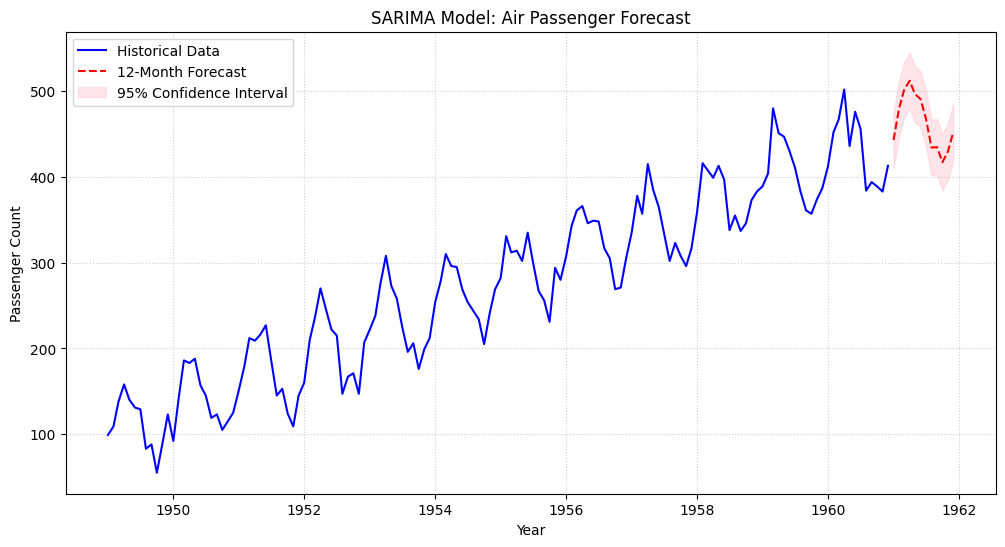

In [5]:
'''8.Train a SARIMA model on the monthly airline passengers dataset.
Forecast the next 12 months and visualize the results.'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

dates = pd.date_range(start='1949-01-01', end='1960-12-01', freq='MS')
n_months = len(dates)

trend = np.linspace(100, 450, n_months)
seasonal = 50 * np.sin(2 * np.pi * np.array(range(n_months)) / 12)
noise = np.random.normal(0, 15, n_months)
passengers = (trend + seasonal + noise).astype(int)

df = pd.DataFrame({'Month': dates, '#Passengers': passengers})
df.set_index('Month', inplace=True)
df.index.freq = 'MS'

print("Dataset sample:\n", df.head())

model = SARIMAX(df['#Passengers'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)

model_fit = model.fit(disp=False)
print("\nModel trained successfully.")

forecast_steps = 12
forecast_results = model_fit.get_forecast(steps=forecast_steps)

forecast_mean = forecast_results.predicted_mean
conf_int = forecast_results.conf_int()

print("\n12-Month Forecast Mean:\n", forecast_mean)

plt.figure(figsize=(12, 6))

plt.plot(df.index, df['#Passengers'], label='Historical Data', color='blue')

plt.plot(forecast_mean.index, forecast_mean, label='12-Month Forecast', color='red', linestyle='--')

plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0],
                 conf_int.iloc[:, 1],
                 color='pink', alpha=0.4, label='95% Confidence Interval')

plt.title('SARIMA Model: Air Passenger Forecast')
plt.xlabel('Year')
plt.ylabel('Passenger Count')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Successfully loaded. Available columns: ['Month', '#Passengers']
Targeting numerical column: '#Passengers' for LOF Anomaly Detection.


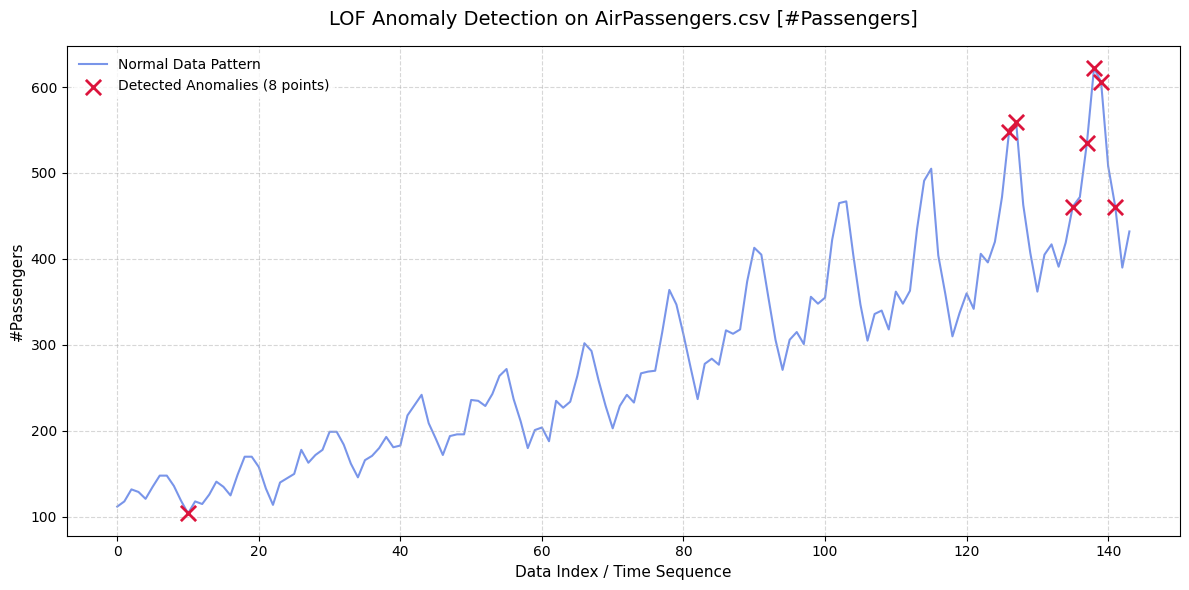

In [10]:
'''9.Apply Local Outlier Factor (LOF) on any numerical dataset to detect
anomalies and visualize them using matplotlib.'''

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

file_path = 'AirPassengers.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Could not find '{file_path}'. Make sure it is in your current working directory.")

data = pd.read_csv(file_path)

data.columns = data.columns.str.strip()
print("Successfully loaded. Available columns:", list(data.columns))

if '#Passengers' in data.columns:
    target_col = '#Passengers'
elif 'Passengers' in data.columns:
    target_col = 'Passengers'
elif 'fare_amount' in data.columns:
    target_col = 'fare_amount'
else:

    numerical_cols = data.select_dtypes(include=[np.number]).columns
    if len(numerical_cols) == 0:
        raise ValueError("The dataset does not contain any numerical columns for anomaly detection.")
    target_col = numerical_cols[0]

print(f"Targeting numerical column: '{target_col}' for LOF Anomaly Detection.")

X = data[target_col].values.reshape(-1, 1)

lof = LocalOutlierFactor(n_neighbors=12, contamination=0.05)
y_pred = lof.fit_predict(X)

data['Anomaly_Score'] = y_pred

outliers = data[data['Anomaly_Score'] == -1]
inliers = data[data['Anomaly_Score'] == 1]

plt.figure(figsize=(12, 6))

plt.plot(data.index, data[target_col], color='royalblue', alpha=0.7, label='Normal Data Pattern', zorder=1)

plt.scatter(outliers.index, outliers[target_col], color='crimson', marker='x',
            s=120, linewidths=2, label=f'Detected Anomalies ({len(outliers)} points)', zorder=2)

plt.title(f'LOF Anomaly Detection on {os.path.basename(file_path)} [{target_col}]', fontsize=14, pad=15)
plt.xlabel('Data Index / Time Sequence', fontsize=11)
plt.ylabel(target_col, fontsize=11)
plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


In [ ]:
'''10. You are working as a data scientist for a power grid monitoring company.
Your goal is to forecast energy demand and also detect abnormal spikes or drops in
real-time consumption data collected every 15 minutes. The dataset includes features
like timestamp, region, weather conditions, and energy usage.
Explain your real-time data science workflow:
i.How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?
ii.Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?
iii.How would you validate and monitor the performance over time?
iv.How would this solution help business decisions or operations? '''

'''ANS. i. Chosen Algorithm: Isolation Forest is highly efficient for streaming,
 high-dimensional telemetry data. It works by randomly isolating observations,
 assigning anomaly scores based on the number of splits required.
 Implementation: Instead of batch processing, you can deploy an online learning
 variant or update rolling windows (e.g., the last 7 days of 15-minute
 intervals) to calculate dynamic thresholds. Points that fall outside a specific
  percentile of the anomaly score are flagged in real-time.

  ii.Chosen Algorithm: SARIMAX (Seasonal AutoRegressive Integrated Moving
  Average with eXogenous variables).
  Why SARIMAX? Power consumption exhibits strong daily (\(24\) hour) and weekly
   (\(7\) day) seasonal patterns. SARIMAX natively models these seasonal
   differences, while the "X" (exogenous) component allows you to feed in
   real-time and forecasted weather data (e.g., temperature, humidity)—a vital
   feature because energy demand is highly non-linear with respect to weather.

   iii.Validation Strategy: Use Time Series Cross-Validation (Rolling Window
   Origin). For instance, train on 30 days of data, predict the next 24 hours,
   roll the window forward one day, and retrain. This mirrors real-world
   streaming deployment.
   Evaluation Metrics: Track Mean Absolute Error (\(\text{MAE} = \frac{1}{n}
   \sum_{i=1}^{n} \vert{}y_i - \hat{y}_i\vert{}\)) and Root Mean Squared Error
   (\(\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}\)) to
    heavily penalize large, dangerous spikes.
    Concept Drift Monitoring: Implement statistical tests like the Population
    Stability Index (PSI) or Kolmogorov-Smirnov (KS) test on incoming weather
    and load data distributions. Set up automated retraining triggers (e.g.,
    via MLflow) if the evaluation metrics degrade past a predefined threshold
    over a rolling 7-day window.

    iv.Dynamic Load Balancing: Short-term SARIMAX forecasts allow grid operators
     to dispatch power from peaker plants or renewable sources precisely when
     demand peaks, preventing blackouts and reducing reliance on expensive,
     emergency power sources.
     Predictive Maintenance & Safety: Real-time anomaly detection flags sudden
     voltage drops or abnormal draw spikes, enabling operations teams to isolate
      faults and dispatch maintenance crews before severe damage or widespread
      outages occur.
      Energy Trading: Accurate short-term load forecasting minimizes grid
      imbalances, avoiding steep financial penalties from wholesale energy
      markets and allowing companies to buy/sell excess capacity profitably.'''